In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [16]:
X,y = make_regression(n_samples=1000, n_features=20, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Linear Regression
linear_regression = LinearRegression()
bagging_regressor = BaggingRegressor(estimator=linear_regression, n_estimators=10, random_state=42)
bagging_regressor.fit(X_train, y_train)
y_pred = bagging_regressor.predict(X_test)
accuracy = r2_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9999997073941684


In [19]:
# Decision Tree Regressor
decision_tree_regressor = DecisionTreeRegressor(random_state=42)    
bagging_regressor = BaggingRegressor(estimator=decision_tree_regressor, n_estimators=10, random_state=42)
bagging_regressor.fit(X_train, y_train)
y_pred = bagging_regressor.predict(X_test)
accuracy = r2_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8035948056981693


In [21]:
# Random Forest Regressor
random_forest_regressor = RandomForestRegressor(random_state=42)
bagging_regressor = BaggingRegressor(estimator=random_forest_regressor, n_estimators=10, random_state=42)
bagging_regressor.fit(X_train, y_train)
y_pred = bagging_regressor.predict(X_test)
accuracy = r2_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8099911692724323


c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
360 fits failed out of a total of 1440.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
360 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\utils\validation.py", line 66, in inner_f
    return f(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^
  File "c:\Users\bhara\anaconda3\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
    

Best Parameters: {'bootstrap': False, 'bootstrap_features': False, 'estimator': LinearRegression(), 'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 10, 'oob_score': False, 'random_state': 42}
Best Score: 0.9999997190135627
Accuracy: 0.9999997047756003


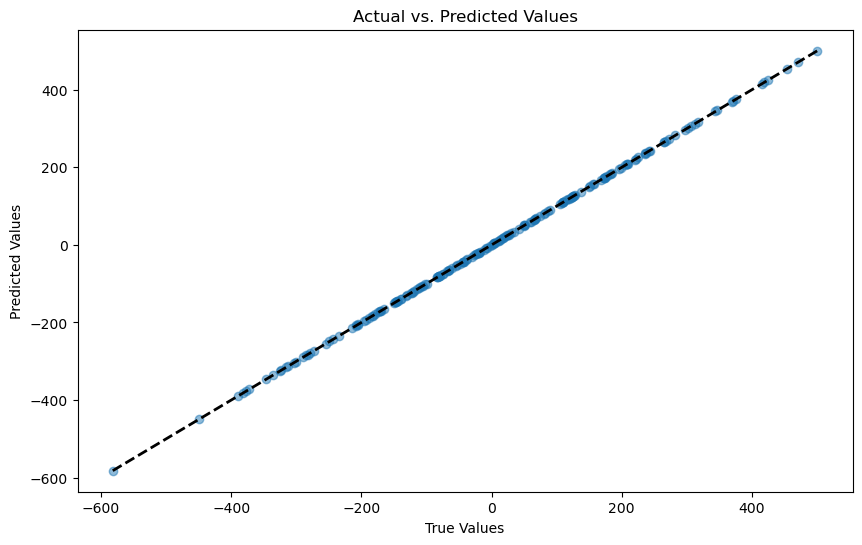

In [ ]:
## grid search for hyperparameter tuning

param_grid = {
    'estimator': [LinearRegression(), DecisionTreeRegressor(), RandomForestRegressor()],
    'n_estimators': [10, 20, 30],
    'random_state': [42],
    'max_features': [0.5, 1.0],
    'max_samples': [0.5, 1.0],
    'bootstrap': [True, False],
    'bootstrap_features': [True, False],
    'oob_score': [True, False]
}

bagging_regressor = BaggingRegressor()
grid_search = GridSearchCV(bagging_regressor, param_grid, cv=5, scoring='r2', n_jobs=-1)
# Assuming X_train and y_train are your training data and labels
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best Parameters:", best_params)
print("Best Score:", best_score)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
accuracy = r2_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

In [32]:
grid_search.cv_results_

{'mean_fit_time': array([4.91333485e-02, 4.00149822e-02, 6.36487007e-02, 4.21028137e-02,
        7.74865150e-02, 6.02448940e-02, 3.42560768e-02, 2.18375683e-02,
        5.35456181e-02, 4.08349037e-02, 7.92022228e-02, 5.95137596e-02,
        3.17847252e-02, 2.66052723e-02, 6.00529194e-02, 4.63028431e-02,
        8.45696449e-02, 7.00030327e-02, 3.08552265e-02, 2.54150867e-02,
        5.75544357e-02, 4.80978966e-02, 8.18474293e-02, 6.45179749e-02,
        5.95170498e-02, 5.02533913e-02, 1.24994755e-01, 1.05287409e-01,
        1.75954533e-01, 1.59209204e-01, 7.69092083e-02, 7.27935314e-02,
        1.47346640e-01, 1.46772480e-01, 2.38546085e-01, 2.16828585e-01,
        7.39270210e-02, 7.13642597e-02, 1.53549004e-01, 1.28985405e-01,
        2.12388086e-01, 1.91020536e-01, 1.14464045e-01, 1.06890154e-01,
        2.25414324e-01, 2.09400463e-01, 3.20664024e-01, 3.11366796e-01,
        3.17922821e+00, 2.97211909e+00, 6.50239515e+00, 6.04615221e+00,
        9.33380370e+00, 9.36255484e+00, 4.51297

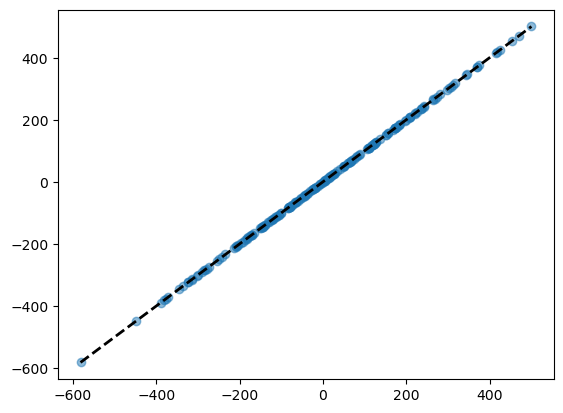

In [26]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

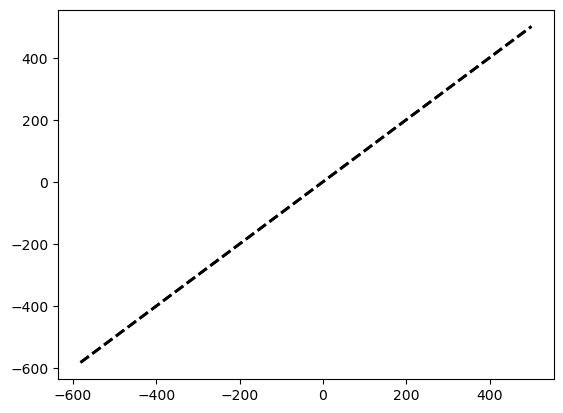

In [ ]:
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
